# FINAL fMRI ANALYSIS NOTEBOOK

## Subject-Level Feature Analysis Pipeline

## 1. SETUP

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
from scipy.stats import pearsonr

# OPTIONAL: improve plot aesthetics
plt.style.use('default')

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. LOAD DATA

In [5]:
DATA_PATH = "/content/drive/MyDrive/CS_4001_Colabs/Final_Project/combined_outputs/caroline_subject_features.csv"  # update if needed

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("Subjects:", df["subject"].nunique())
display(df.head())

Dataset shape: (3, 13)
Subjects: 3


,fd_mean,fd_max,fd_std,fd_spikes,dvars_mean,bold_mean_signal,bold_std_signal,bold_mean_voxel_variance,bold_global_mean,bold_global_std,spectral_total_power,spectral_low_freq_power,subject
0,0.203806,0.458892,0.089067,0,1.005190,3071.164839,3174.634520,36699.885607,3071.164839,6.680519,2.246192e+12,2.246189e+12,sub-NDARINVAG339WHH
1,0.246678,0.505903,0.111866,1,1.039142,1669.154344,2481.384973,25962.367727,1669.154344,3.588317,6.634889e+11,6.634880e+11,sub-NDARINVZX212UNE
2,0.322287,1.071488,0.178304,74,1.030614,2260.610718,3267.167161,96428.246386,2260.610718,19.008128,1.217045e+12,1.217030e+12,sub-NDARINVAG023WG3


## 3. BASIC DATA OVERVIEW

In [6]:
print("\nMissing values per column:")
print(df.isnull().sum())

print("\nSummary statistics:")
display(df.describe())


Missing values per column:
fd_mean                     0
fd_max                      0
fd_std                      0
fd_spikes                   0
dvars_mean                  0
bold_mean_signal            0
bold_std_signal             0
bold_mean_voxel_variance    0
bold_global_mean            0
bold_global_std             0
spectral_total_power        0
spectral_low_freq_power     0
subject                     0
dtype: int64

Summary statistics:


,fd_mean,fd_max,fd_std,fd_spikes,dvars_mean,bold_mean_signal,bold_std_signal,bold_mean_voxel_variance,bold_global_mean,bold_global_std,spectral_total_power,spectral_low_freq_power
count,3.000000,3.000000,3.000000,3.00000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000e+00,3.000000e+00
mean,0.257590,0.678761,0.126412,25.00000,1.024982,2333.643300,2974.395551,53030.166573,2333.643300,9.758988,1.375575e+12,1.375569e+12
std,0.059989,0.340923,0.046363,42.43819,0.017663,703.852737,429.459131,37965.360147,703.852737,8.157841,8.031727e+11,8.031729e+11
min,0.203806,0.458892,0.089067,0.00000,1.005190,1669.154344,2481.384973,25962.367727,1669.154344,3.588317,6.634889e+11,6.634880e+11
25%,0.225242,0.482397,0.100466,0.50000,1.017902,1964.882531,2828.009746,31331.126667,1964.882531,5.134418,9.402668e+11,9.402591e+11
50%,0.246678,0.505903,0.111866,1.00000,1.030614,2260.610718,3174.634520,36699.885607,2260.610718,6.680519,1.217045e+12,1.217030e+12
75%,0.284483,0.788695,0.145085,37.50000,1.034878,2665.887778,3220.900840,66564.065996,2665.887778,12.844324,1.731619e+12,1.731610e+12
max,0.322287,1.071488,0.178304,74.00000,1.039142,3071.164839,3267.167161,96428.246386,3071.164839,19.008128,2.246192e+12,2.246189e+12


## 4. MOTION ANALYSIS (CORE RESULT)

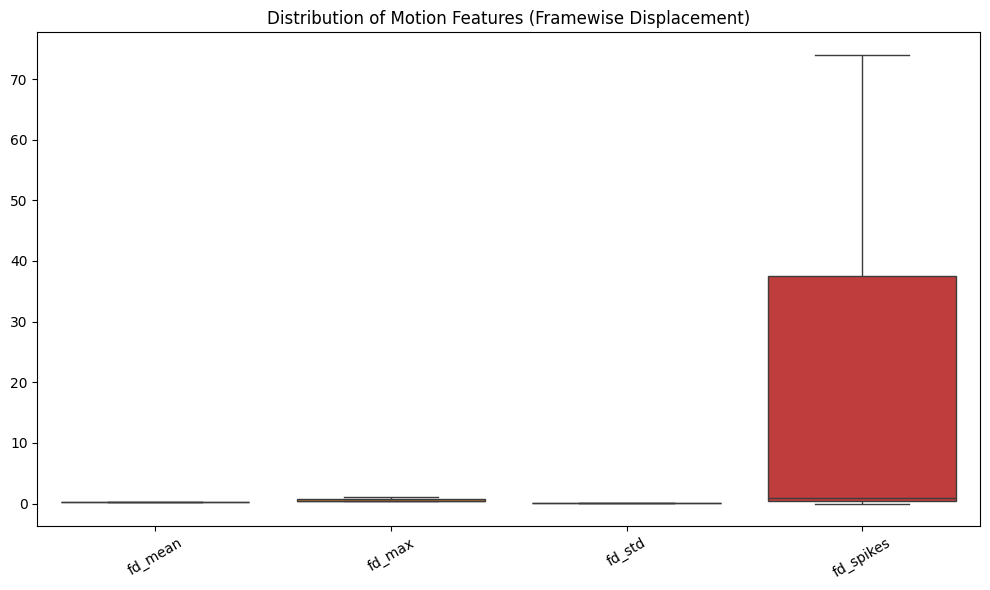

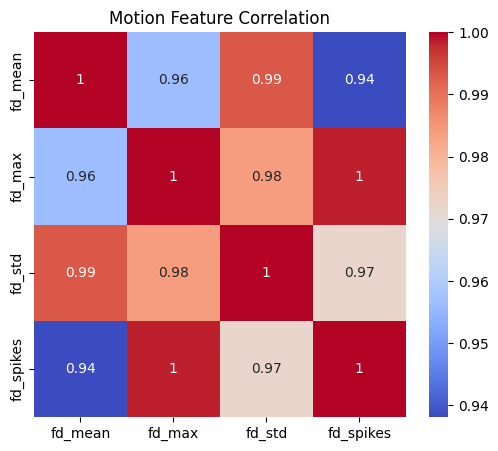

In [7]:
motion_cols = ["fd_mean", "fd_max", "fd_std", "fd_spikes"]

plt.figure(figsize=(10,6))
sns.boxplot(data=df[motion_cols])
plt.title("Distribution of Motion Features (Framewise Displacement)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Correlation between motion features
plt.figure(figsize=(6,5))
sns.heatmap(df[motion_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Motion Feature Correlation")
plt.show()

## 5. DVARS ANALYSIS

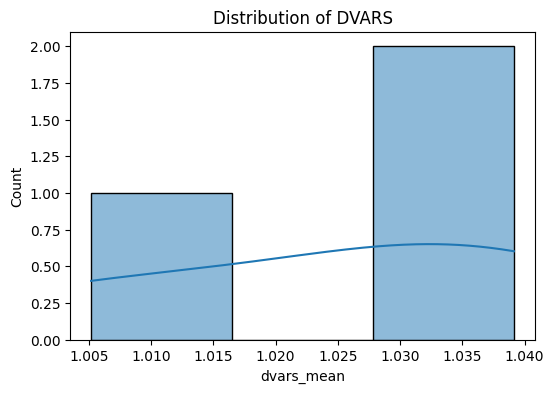

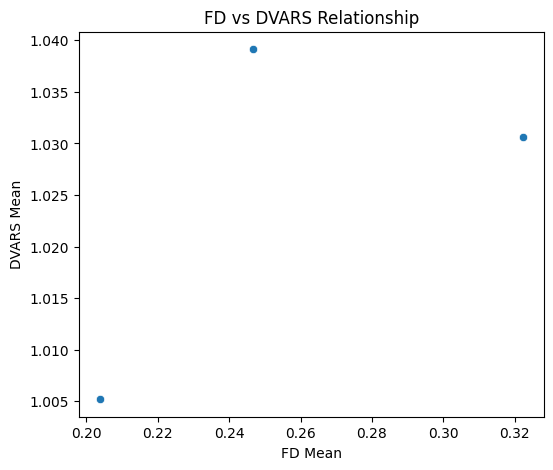

In [8]:
if "dvars_mean" in df.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df["dvars_mean"], kde=True)
    plt.title("Distribution of DVARS")
    plt.show()

# FD vs DVARS relationship
if "dvars_mean" in df.columns:
    plt.figure(figsize=(6,5))
    sns.scatterplot(x=df["fd_mean"], y=df["dvars_mean"])
    plt.title("FD vs DVARS Relationship")
    plt.xlabel("FD Mean")
    plt.ylabel("DVARS Mean")
    plt.show()

## 6. BOLD / SIGNAL FEATURES


BOLD-related features: ['bold_mean_signal', 'bold_std_signal', 'bold_mean_voxel_variance', 'bold_global_mean', 'bold_global_std', 'spectral_total_power', 'spectral_low_freq_power']


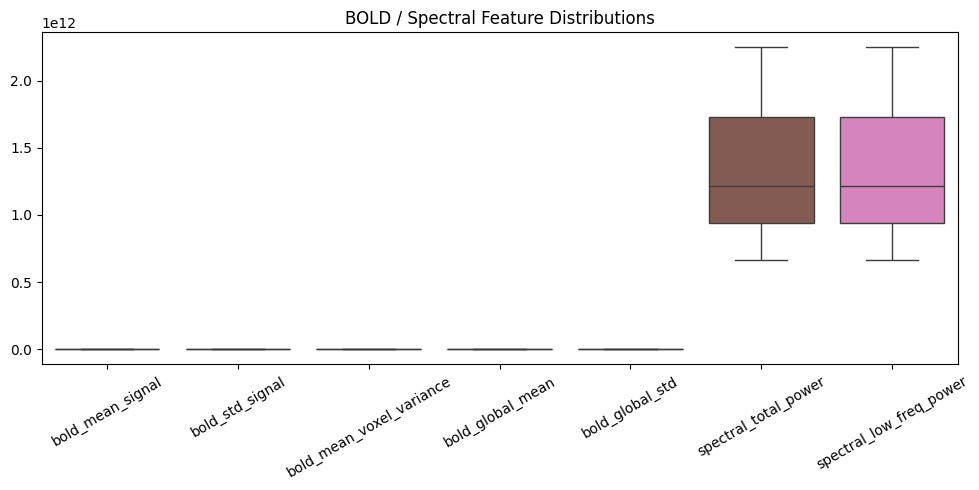

In [9]:
bold_cols = [c for c in df.columns if "bold" in c or "spectral" in c]

print("\nBOLD-related features:", bold_cols)

if len(bold_cols) > 0:
    plt.figure(figsize=(10,5))
    sns.boxplot(data=df[bold_cols])
    plt.xticks(rotation=30)
    plt.title("BOLD / Spectral Feature Distributions")
    plt.tight_layout()
    plt.show()

## 7. FEATURE CORRELATION HEATMAP

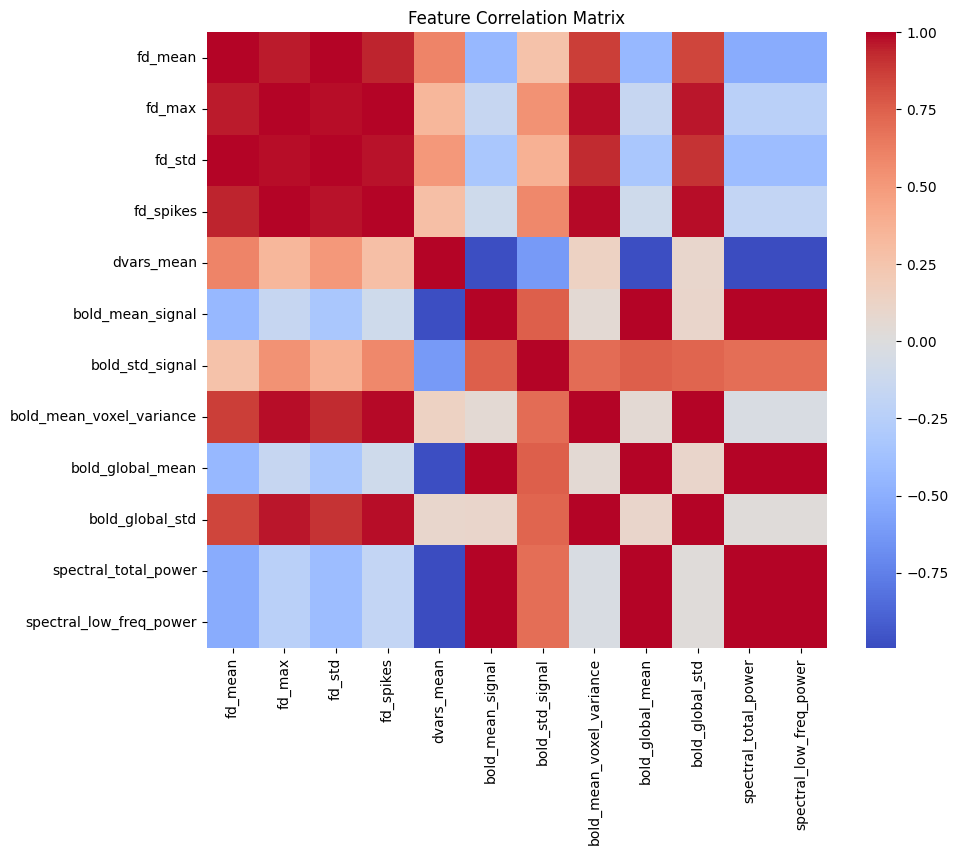

In [10]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.show()

## 8. SIMPLE FEATURE RELATIONSHIPS

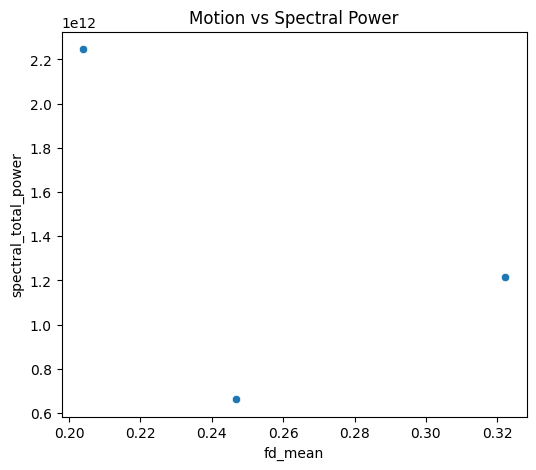

In [11]:
# Example: FD vs spectral power
if "spectral_total_power" in df.columns:
    plt.figure(figsize=(6,5))
    sns.scatterplot(x=df["fd_mean"], y=df["spectral_total_power"])
    plt.title("Motion vs Spectral Power")
    plt.show()

## 9. OPTIONAL: SIMPLE PREDICTIVE MODEL (IF TARGET EXISTS)

In [12]:
if "FTND" in df.columns:
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import r2_score

    target = df["FTND"]
    features = df.drop(columns=["subject", "FTND"], errors="ignore").select_dtypes(include=[np.number])

    X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

    model = RandomForestRegressor(n_estimators=200, random_state=42)
    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    print("R2 score:", r2_score(y_test, preds))

    importances = pd.Series(model.feature_importances_, index=features.columns)
    importances.sort_values().plot(kind="barh", figsize=(8,6))
    plt.title("Feature Importance (Random Forest)")
    plt.show()

## 10. EXPORT SUMMARY TABLE

In [13]:
summary = df.describe().T
summary.to_csv("feature_summary_table.csv")

print("Saved summary table: feature_summary_table.csv")

Saved summary table: feature_summary_table.csv
